## Implementación de modelos supervisados de tipo regresión.

El objetivo de este Notebook es desarrollar y evaluar modelos de aprendizaje supervisado para tareas de regresión, orientados a predecir variables cuantitativas continuas en el contexto del proyecto. Se justificara la selección de algoritmos y se analizarán métricas clave (R2, RMSE, MAE) para garantizar precisión interpretabilidad y generalización.

#### Herramientas necesarias

In [2]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt

import os
import sys
sys.path.insert(0, os.path.abspath("../"))
import src.visualizaciones as visualizaciones

from IPython.display import display

# omite advertencias
import warnings
warnings.filterwarnings("ignore")

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import hashlib

import scipy.stats as ss

#### Cargar set de datos

In [3]:
df = pd.read_csv("../data/Telco_Customer_Churn_Dataset_crudo.csv")

#### Información inicial de Data

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [6]:
df.shape

(7043, 21)

* Este conjunto de datos consiste en 7043 registros y 21 características
* El dataset tiene muchas características como data de texto y probablemente sean variables categóricas
* **TotalCharges** contiene valores numéricos pero está almacenada como strings. Vamos a convertir esta variable a tipo numérica (float)
* La variable **SeniorCitizen** indica si el cliente es adulto mayor (0 = "no", 1 = "sí"). Al ser una variable categórica, la convertiremos de tipo numérico a object

# Manipulación de Datos

In [7]:
# convertir columnas de tipo string a object
for columna in df.select_dtypes(include=['string']).columns:
        df[columna] = df[columna].astype('object')
print(f"Total de columnas convertidas a object: {len(df.select_dtypes(include=['object']).columns)}")

Total de columnas convertidas a object: 18


In [8]:
# convertir TotalCharges a numérico
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print("TotalCharges convertido a numérico.")

TotalCharges convertido a numérico.


In [9]:
# convertir SeniorCitizen a object para que sea categórico
df['SeniorCitizen'] = df['SeniorCitizen'].replace({0: '0', 1: '1'}).astype(object)
print("SeniorCitizen convertido a object.")

SeniorCitizen convertido a object.


In [10]:
# información general del DataFrame
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   object 
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 
 17  Paymen

- En esta ocasión nuestra variable objetivo que guiara nuestra exploración es 

#### Implementación de Anonimización

* De acuerdo con la legislación sobre protección de la vida privada, almacenar de forma directa el ID del cliente (CustomerID) junto con su comportamiento financiero expone a la empresa a severas multas.

In [11]:
def anonimizar(texto):
    # Genera un Hash único para el nombre (Irreversible)
    return hashlib.sha256(texto.encode()).hexdigest()

# Aplicar a la columna sensible
df['customerID_Hash'] = df['customerID'].apply(anonimizar)

# Eliminar el dato original
df.drop('customerID', axis=1, inplace=True)

In [12]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customerID_Hash
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,...,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,f3f9002e121cbbcc038f195a656a32a17395c6ce1815e8...
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,...,No,No,No,One year,No,Mailed check,56.95,1889.50,No,5f362546eb7515f442a40d3d9bf632e4a481c92bcb0529...
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,...,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,701bf78bdf332d16ec5fb80a1affac3a080a8b9c258c2d...
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,...,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,59a0e1b332a6b6ba8f6a72f74085e6498e8c54a5d18191...
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,...,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,66370db9e1bb6a851fa692a2499f4f1356efab8e5abf90...


# Análisis Exploratorio de Datos

In [13]:
# conteo de valores nulos por columna
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
customerID_Hash      0
dtype: int64

* La columna **TotalCharges** tienen algunos valores faltantes

In [14]:
# muestra registros con valores nulos en TotalCharges
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,customerID_Hash
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,...,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,3fc827a9c771a5597e1b9563ba46bd77b5a33daad5f094...
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,cc8dcc067e61d7292f35e1d99cf280c8f1663b1d6b9dc0...
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,...,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,58d283200bed248b5d1e0eb621b905ecbb502854900fb3...
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No,ea0b24cc08647ff604fd33a68453a8adb51fdc83f96386...
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,...,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No,0e9341d2f088bdb7928f46db857c21c35c9eaafb56084d...
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No,8c6c0d363aa75ea0795734b32d5adcbbd77845674cc04e...
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No,f3d447e5d65b5d31443dae3b897268f29b906c53a3bb29...
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No,3c63ffbaff09f452804dc16726922dfddfb6354320fd79...
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,...,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No,01b32519075edcfd0f091c271f6cc693e2ed154b5a38c9...
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,...,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No,53819de429be29e2cf2d830bf81fd95987cea3db3612ce...


* En los registros donde **TotalCharges** presenta valores nulos, la antiguedad del cliente (**tenure**) es igual a 0. Por este motivo, y dado que la baja cantidad de valores faltantes no afectará la calidad del conjunto, es seguro reemplazar dichos valores faltantes por 0

In [15]:
# reemplazar valores nulos de TotalCharges por 0
df["TotalCharges"] = df["TotalCharges"].fillna(0)
print("Valores nulos de TotalCharges reemplazados por 0.")

Valores nulos de TotalCharges reemplazados por 0.


#### Análisis de valores duplicados

In [16]:
# registros duplicados
print(f"Cantidad de registros duplicados: {df.duplicated().sum()}")

Cantidad de registros duplicados: 0


* Tras la revisión, no se encontraron valores duplicados en el conjunto de datos

#### Análisis de valores atípicos

In [17]:
# buscar valores atípicos usando el rango intercuartil
columnas_numericas = ["tenure", "MonthlyCharges", "TotalCharges"]

for columna in columnas_numericas:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    rango_intercuartil = q3 - q1

    limite_inferior = q1 - 1.5 * rango_intercuartil
    limite_superior = q3 + 1.5 * rango_intercuartil

    valores_atipicos = df[
        (df[columna] < limite_inferior) | (df[columna] > limite_superior)
    ]

    if len(valores_atipicos) > 0:
        print(f"{columna}: sí presenta valores atípicos ({len(valores_atipicos)} registros).")
    else:
        print(f"{columna}: no presenta valores atípicos.")

tenure: no presenta valores atípicos.
MonthlyCharges: no presenta valores atípicos.
TotalCharges: no presenta valores atípicos.


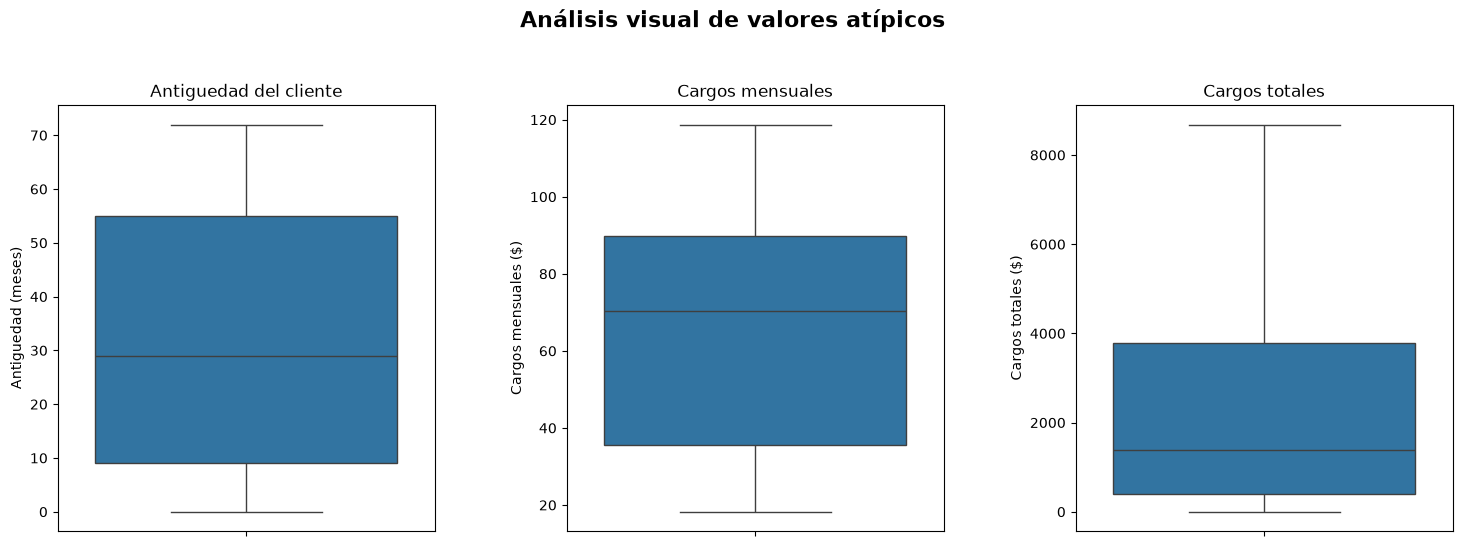

In [18]:
# crear una figura con múltiples espacios
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("Análisis visual de valores atípicos", fontsize=16, fontweight="bold")

# dibujar cada gráfico de caja con nombres descriptivos en español
sns.boxplot(y=df["tenure"], ax=axes[0])
axes[0].set_title("Antiguedad del cliente")
axes[0].set_xlabel("")
axes[0].set_ylabel("Antiguedad (meses)")

sns.boxplot(y=df["MonthlyCharges"], ax=axes[1])
axes[1].set_title("Cargos mensuales")
axes[1].set_xlabel("")
axes[1].set_ylabel("Cargos mensuales ($)")

sns.boxplot(y=df["TotalCharges"], ax=axes[2])
axes[2].set_title("Cargos totales")
axes[2].set_xlabel("")
axes[2].set_ylabel("Cargos totales ($)")

plt.subplots_adjust(wspace=0.35, top=0.82)
plt.show()

* No se encontraron valores atípicos en las variables numéricas analizadas

#### Estadísticas básicas

In [19]:
# estadísticas descriptivas de las variables categóricas
df.describe(include="object").T.drop("customerID_Hash", axis=0)

,count,unique,top,freq
gender,7043,2,Male,3555
SeniorCitizen,7043,2,0,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,4933
PhoneService,7043,2,Yes,6361
MultipleLines,7043,3,No,3390
InternetService,7043,3,Fiber optic,3096
OnlineSecurity,7043,3,No,3498
OnlineBackup,7043,3,No,3088
DeviceProtection,7043,3,No,3095


Hallazgos relevantes:

* La distribución por género es equilibrada: hay 3555 hombres y 3488 mujeres
* La clase positiva **Churn = Yes**, que representa a los clientes que sí abandonan el servicio, contiene 1869 registros (26,5%)
* La mayoría de los clientes no son adultos mayores: **SeniorCitizen** = 0 representa aproximadamente el 83,8%
* El contrato más frecuente es mensual, con 3875 clientes, lo que representa aproximadamente el 55%
* Cerca del 90,3% de los clientes tiene servicio telefónico

In [20]:
# estadísticas descriptivas de variables numéricas
df.describe(include=['int64', 'float64']).T

,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.00,55.00,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.35,89.85,118.75
TotalCharges,7043.0,2279.734304,2266.794470,0.00,398.55,1394.55,3786.60,8684.80


- La antiguedad mediana es de 29 meses, mientras que la media es de 32,37 meses
- Los cargos mensuales tienen una mediana de $70,35, con valores entre $18,25 y $118,75
- **TotalCharges** presenta una mediana de $1394,55 y una media de $2279,73

## Análisis Descriptivo

### Distribuciones de las variables numericas

Text(0.5, 1.0, 'Distribución de la variable TotalCharges')

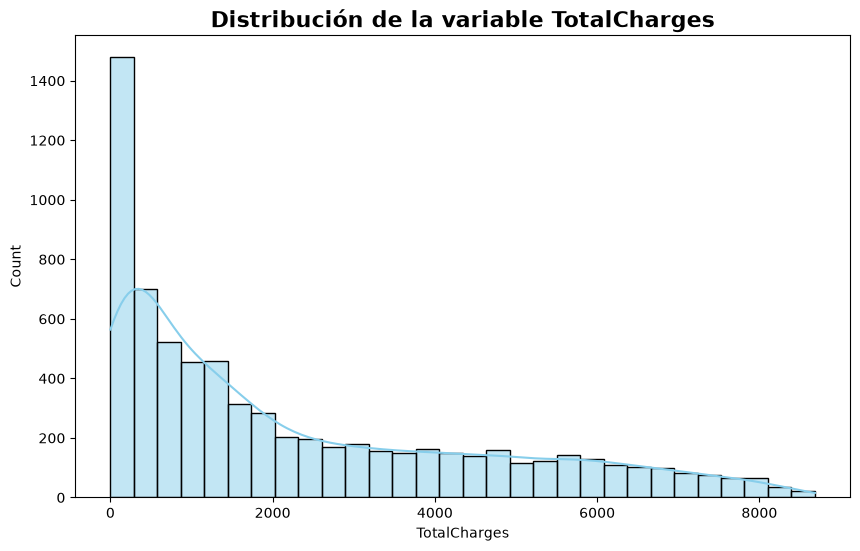

In [27]:
#Distribución de la variable total_charges
plt.figure(figsize=(10, 6))
sns.histplot(df["TotalCharges"], bins=30, kde=True, color="skyblue")
plt.title("Distribución de la variable TotalCharges", fontsize=16, fontweight="bold")

Text(0.5, 1.0, 'Distribución de la variable MonthlyCharges')

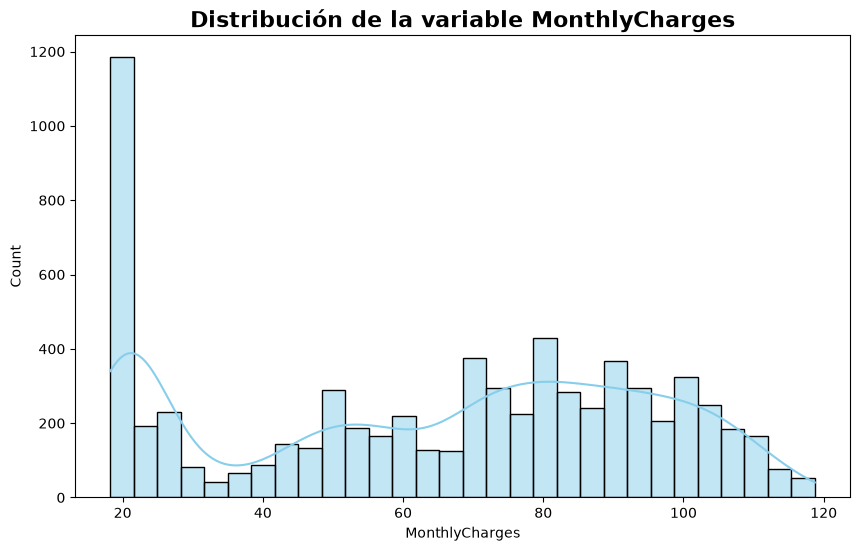

In [28]:
#Distribución de la variable monthly_charges
plt.figure(figsize=(10, 6))
sns.histplot(df["MonthlyCharges"], bins=30, kde=True, color="skyblue")
plt.title("Distribución de la variable MonthlyCharges", fontsize=16, fontweight="bold")

Text(0.5, 1.0, 'Distribución de la variable Tenure')

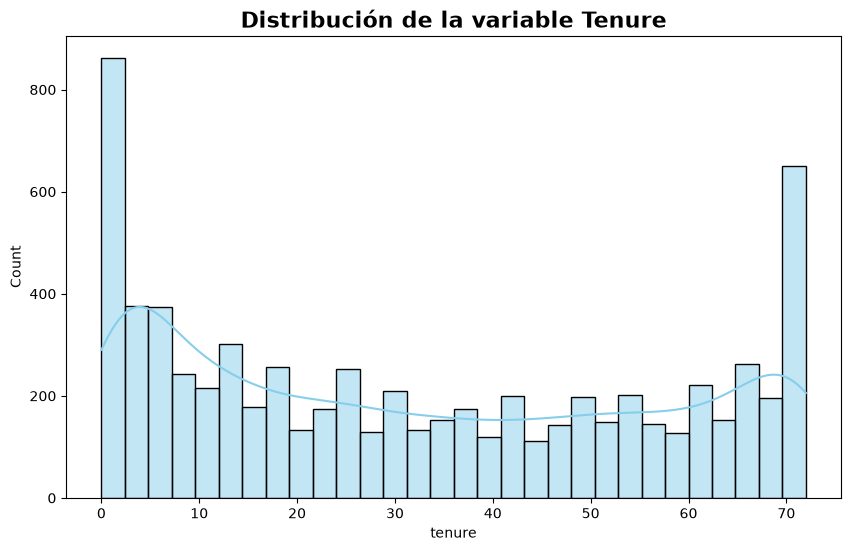

In [30]:
#Distribución de la variable monthly_charges
plt.figure(figsize=(10, 6))
sns.histplot(df["tenure"], bins=30, kde=True, color="skyblue")
plt.title("Distribución de la variable Tenure", fontsize=16, fontweight="bold")

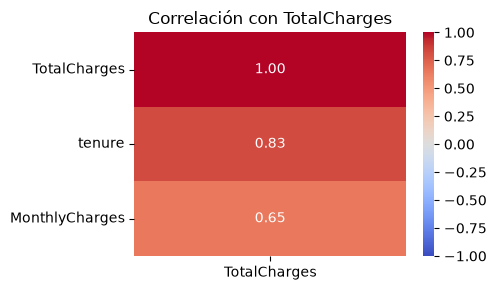

In [ ]:
# mapa de calor matriz de correlaciones variables numéricas
columnas = ["tenure", "MonthlyCharges", "TotalCharges"]

correlacion_total = (
    df[columnas]
    .corr()[["TotalCharges"]]
    .sort_values("TotalCharges", ascending=False)
)

plt.figure(figsize=(5, 3))
sns.heatmap(
    correlacion_total,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    fmt=".2f"
)
plt.title("Correlación con TotalCharges")
plt.tight_layout()
plt.show()

<Axes: title={'center': 'Cargos totales vs antiguedad del cliente (en meses)'}, xlabel='Antiguedad del cliente (meses)', ylabel='Cargos totales ($)'>

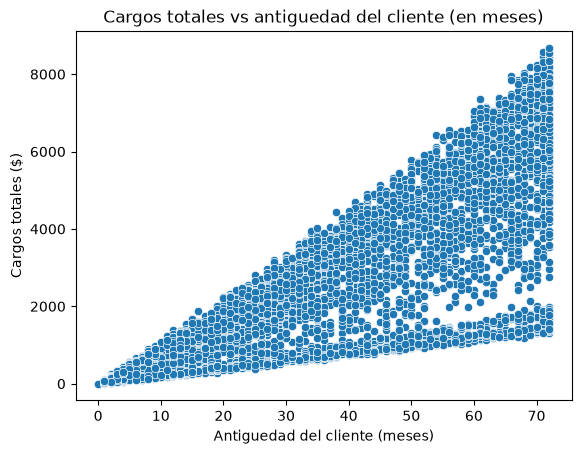

In [32]:
plt.title("Cargos totales vs antiguedad del cliente (en meses)")
plt.xlabel("Antiguedad del cliente (meses)")
plt.ylabel("Cargos totales ($)")
sns.scatterplot(x='tenure', y='TotalCharges', data=df)

- Visualmente, parece que existe una relación lineal general entre estas variables. Los montos financieros acumulado que el cliente ha pagado a lo largo de toda su historia con la empresa (total_charges) aumentan a medida que aumenta La cantidad de meses que el cliente ha mantenido su contrato activo con la empresa (tenure). 

<Axes: title={'center': 'Cargos totales vs Cargos mensuales'}, xlabel='Cargos mensuales ($)', ylabel='Cargos totales ($)'>

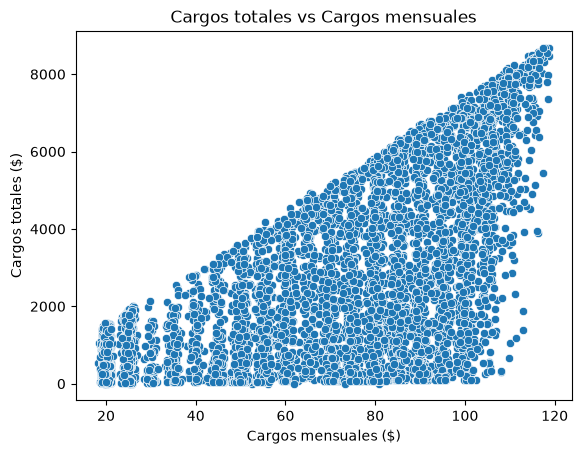

In [33]:
plt.title("Cargos totales vs Cargos mensuales")
plt.xlabel("Cargos mensuales ($)")
plt.ylabel("Cargos totales ($)")
sns.scatterplot(x='MonthlyCharges', y='TotalCharges', data=df)